<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/PCD_DETECTION_RAMBU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Essential Libraries
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.0/984.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
# Import Essential Libraries
import os
import random
import pandas as pd
from PIL import Image
import cv2
from ultralytics import YOLO
from IPython.display import Video
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
import pathlib
import glob
from tqdm.notebook import trange, tqdm
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Configure the visual appearance of Seaborn plots
sns.set(rc={'axes.facecolor': '#eae8fa'}, style='darkgrid')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# prompt: buat code untuk unzip file datapalangnew.zip

!unzip datapalangnew.zip


Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: datapalangnew/train/labels/00000_00003_00026_png.rf.1f6b33373353f896f2c2025ffd264e51.txt  
  inflating: datapalangnew/train/labels/00000_00003_00026_png.rf.a3b6c2dcd4ee9a8064667b7bb266590b.txt  
  inflating: datapalangnew/train/labels/00000_00003_00027_png.rf.c1381ed46ee0d7e21877ea3d7ef86127.txt  
  inflating: datapalangnew/train/labels/00000_00003_00029_png.rf.8e24d2606537779612888c6a06c7043d.txt  
  inflating: datapalangnew/train/labels/00000_00004_00000_png.rf.45dccdbf08ed12f25d7742d8bf88c102.txt  
  inflating: datapalangnew/train/labels/00000_00004_00001_png.rf.557d3494b3e633e29069a6f42918334e.txt  
  inflating: datapalangnew/train/labels/00000_00004_00002_png.rf.3e3e95e1ba16cac885d3de7864a40fb4.txt  
  inflating: datapalangnew/train/labels/00000_00004_00003_png.rf.9c6ba4d0186eec82a26bddc9a1204efb.txt  
  inflating: datapalangnew/train/labels/00000_00004_00003_png.rf.a8220aafd1a7f7bba4391bd0a10cdd2f.txt  
  inf

In [ ]:
os.listdir('/content/datapalangnew/')

['test', 'train', 'valid', 'data.yaml']

In [ ]:
!pip install Pillow


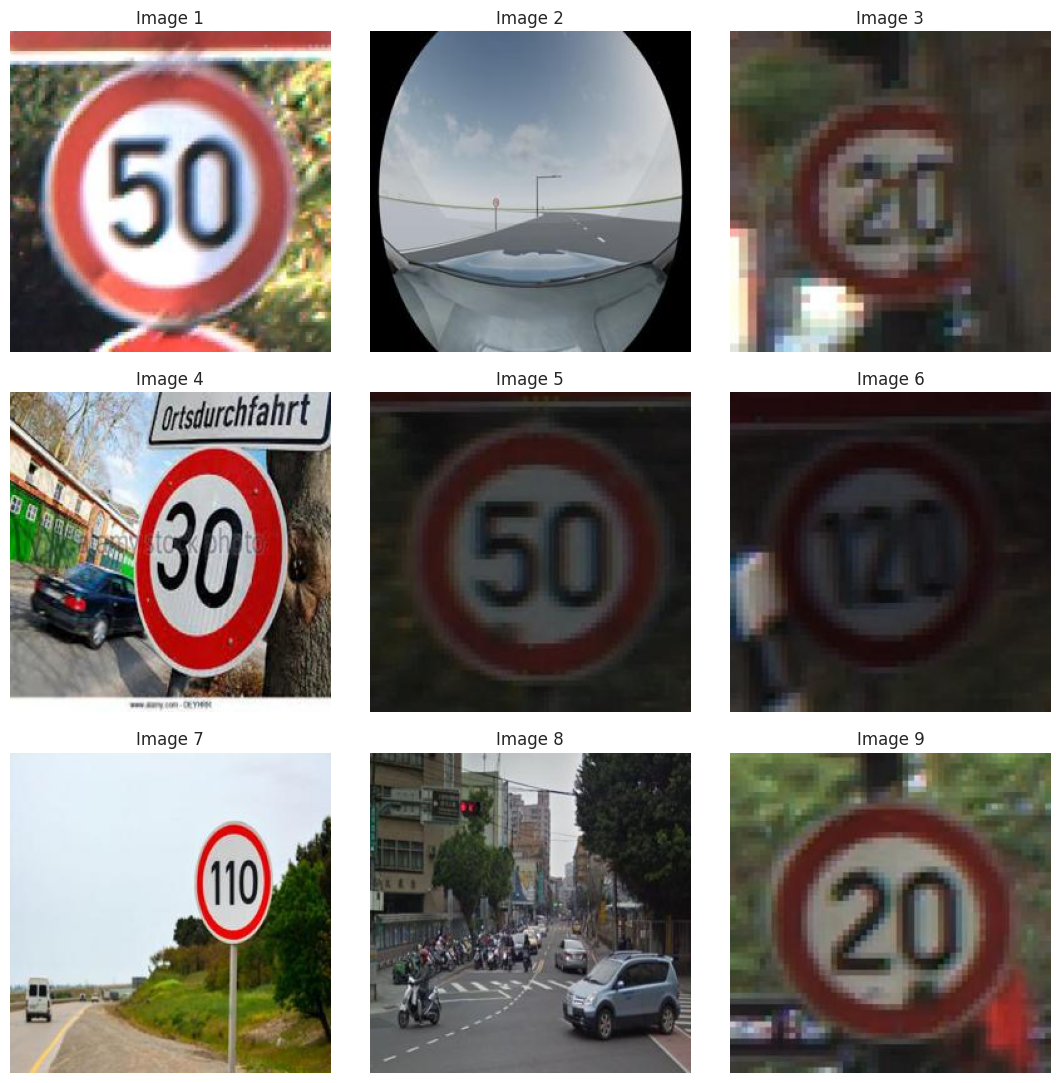

In [ ]:
Image_dir = '/content/datapalangnew/train/images'

num_samples = 9
image_files = os.listdir(Image_dir)

# Randomly select num_samples images
rand_images = random.sample(image_files, num_samples)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for i in range(num_samples):
    image = rand_images[i]
    ax = axes[i // 3, i % 3]
    ax.imshow(plt.imread(os.path.join(Image_dir, image)))
    ax.set_title(f'Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Get the size of the image
image = cv2.imread("/content/datapalangnew/train/images/000000_jpg.rf.b11f308f16626f9f795a148029c46d10.jpg")
h, w, c = image.shape
print(f"The image has dimensions {w}x{h} and {c} channels.")

The image has dimensions 256x256 and 3 channels.


100%|██████████| 6.25M/6.25M [00:00<00:00, 14.7MB/s]



image 1/1 /content/datapalangnew/train/images/000000_jpg.rf.b11f308f16626f9f795a148029c46d10.jpg: 256x256 (no detections), 241.2ms
Speed: 5.3ms preprocess, 241.2ms inference, 11.9ms postprocess per image at shape (1, 3, 256, 256)


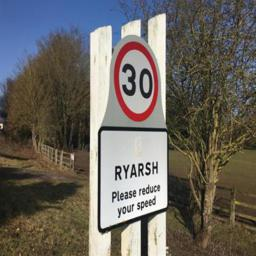

In [ ]:
# Use a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Use the model to detect object
image = "/content/datapalangnew/train/images/000000_jpg.rf.b11f308f16626f9f795a148029c46d10.jpg"
result_predict = model.predict(source = image, imgsz=(256))

# show results
plot = result_predict[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

In [ ]:
!pip install --upgrade ultralytics ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 MB 7.4 MB/s eta 0:00:00


In [ ]:
# Build from YAML and transfer weights
Final_model = YOLO('yolov8n.yaml').load('yolov8n.pt')

# Training The Final Model
Result_Final_model = Final_model.train(data="/content/datapalangnew/data.yaml",epochs=50, imgsz = 256, batch = 2 ,lr0=0.001, optimizer='AdamW', dropout= 0.15, device = "cpu")


Transferred 355/355 items from pretrained weights
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=/content/datapalangnew/data.yaml, epochs=50, time=None, patience=100, batch=2, imgsz=256, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=None, name=train12, exist_ok=False, pretrained=yolov8n.pt, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.15, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False,

train: Scanning /content/datapalangnew/train/labels.cache... 3530 images, 3 backgrounds, 0 corrupt: 100%|██████████| 3530/3530 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 302.6±165.7 MB/s, size: 9.3 KB)



val: Scanning /content/datapalangnew/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:00<?, ?it/s]

Plotting labels to runs/detect/train12/labels.jpg... 


...

      50/50         0G     0.5672     0.5742     0.8929          2        256: 100%|██████████| 1765/1765 [08:42<00:00,  3.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 201/201 [00:42<00:00,  4.68it/s]

                   all        801        944      0.838      0.759      0.792      0.696



50 epochs completed in 8.071 hours.
Optimizer stripped from runs/detect/train12/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train12/weights/best.pt, 6.2MB

Validating runs/detect/train12/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 201/201 [00:39<00:00,  5.12it/s]


                   all        801        944      0.832      0.763      0.793      0.697
           Lampu Hijau         87        122       0.66      0.385      0.379      0.204
           Lampu Merah         74        108      0.501      0.381      0.349      0.186
   Batas Kecepatan 100         52         52      0.924      0.939      0.945      0.849
   Batas Kecepatan 110         17         17      0.556      0.765      0.554      0.509
   Batas Kecepatan 120         60         60       0.86      0.833      0.901      0.834
    Batas Kecepatan 20         56         56      0.991      0.893      0.952      0.823
    Batas Kecepatan 30         71         74      0.969      0.843      0.932      0.868
    Batas Kecepatan 40         53         55      0.905      0.855      0.905      0.775
    Batas Kecepatan 50         68         71      0.901      0.768      0.866      0.793
    Batas Kecepatan 60         76         76      0.958      0.803       0.89      0.819
    Batas Kecepatan 7

In [ ]:
list_of_metrics = ["P_curve.png","R_curve.png","confusion_matrix.png"]

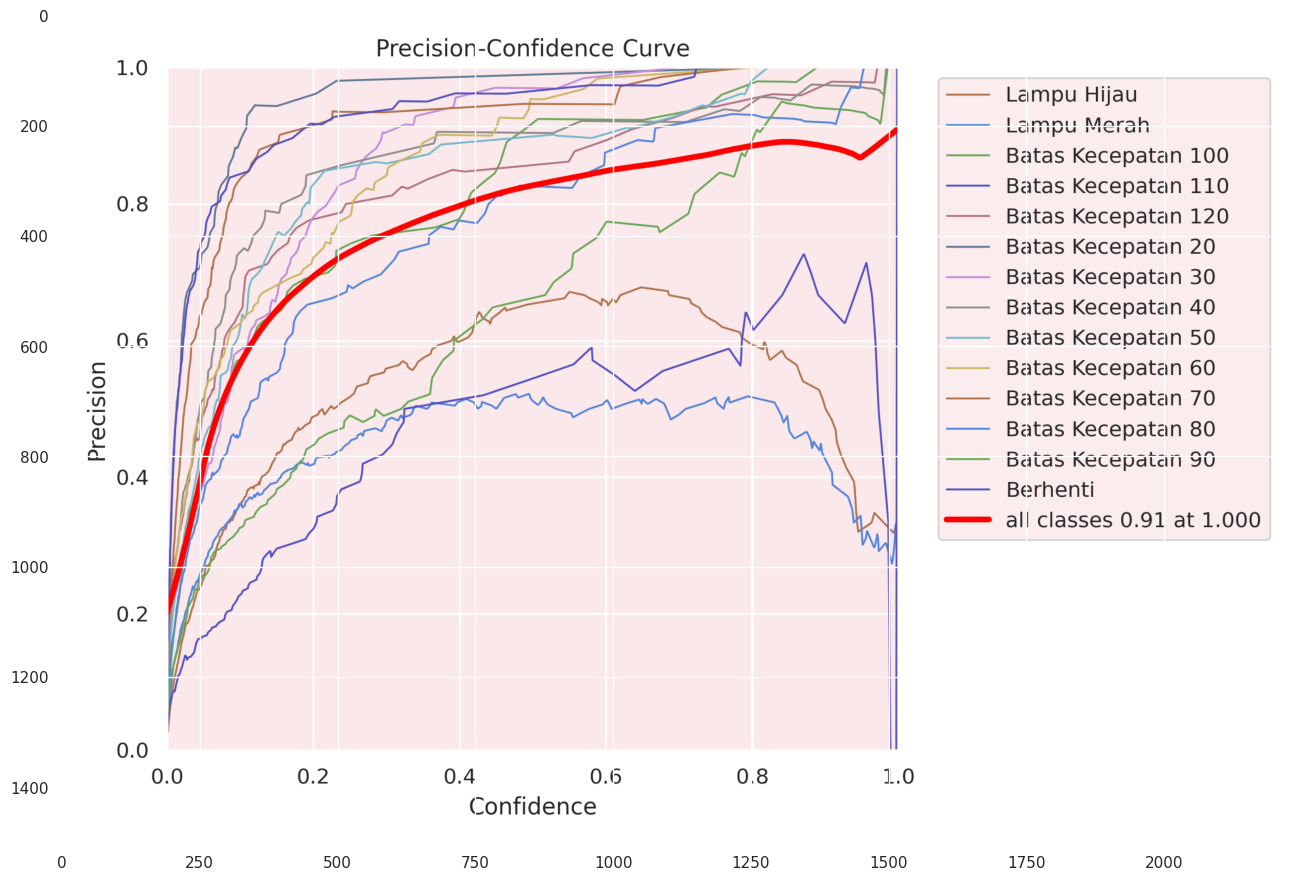

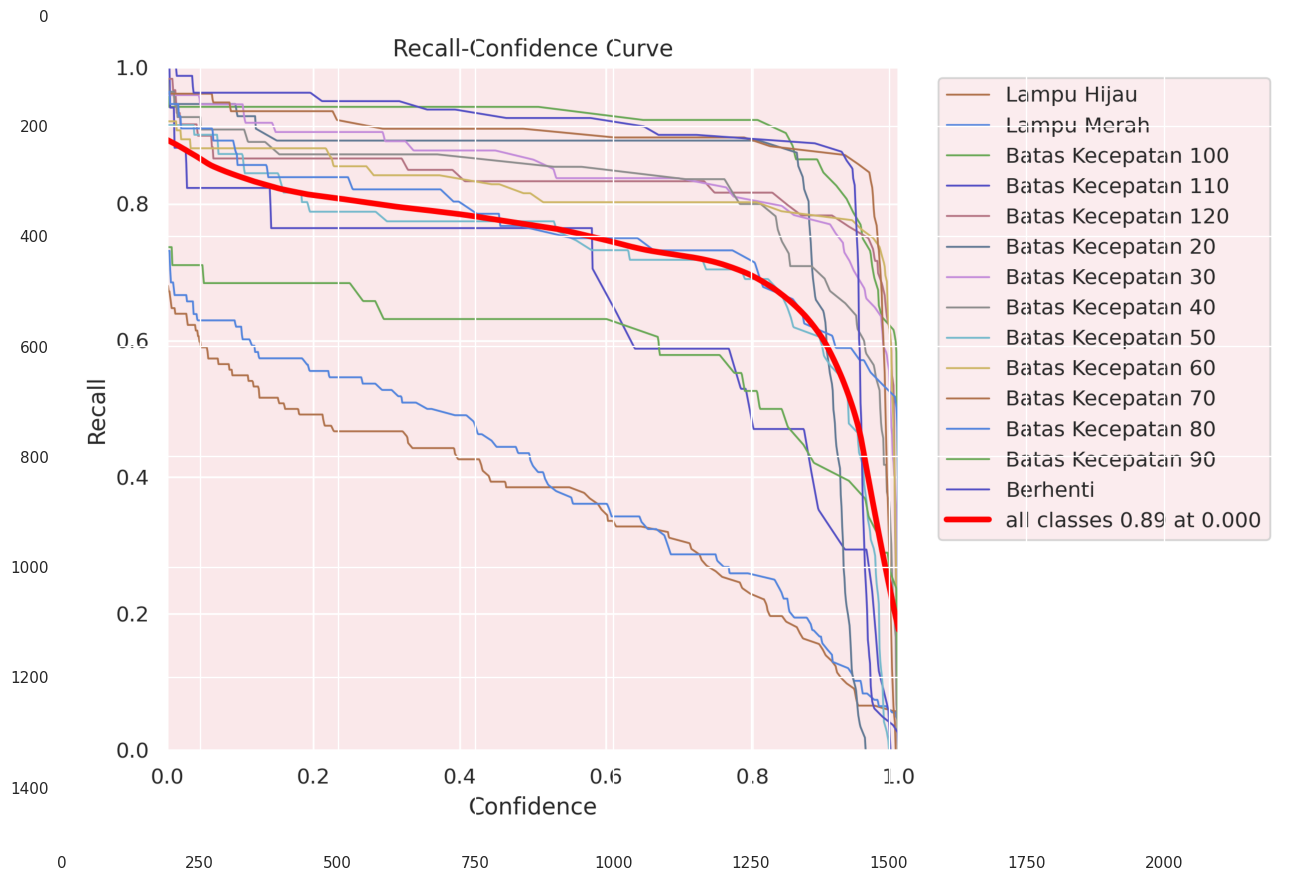

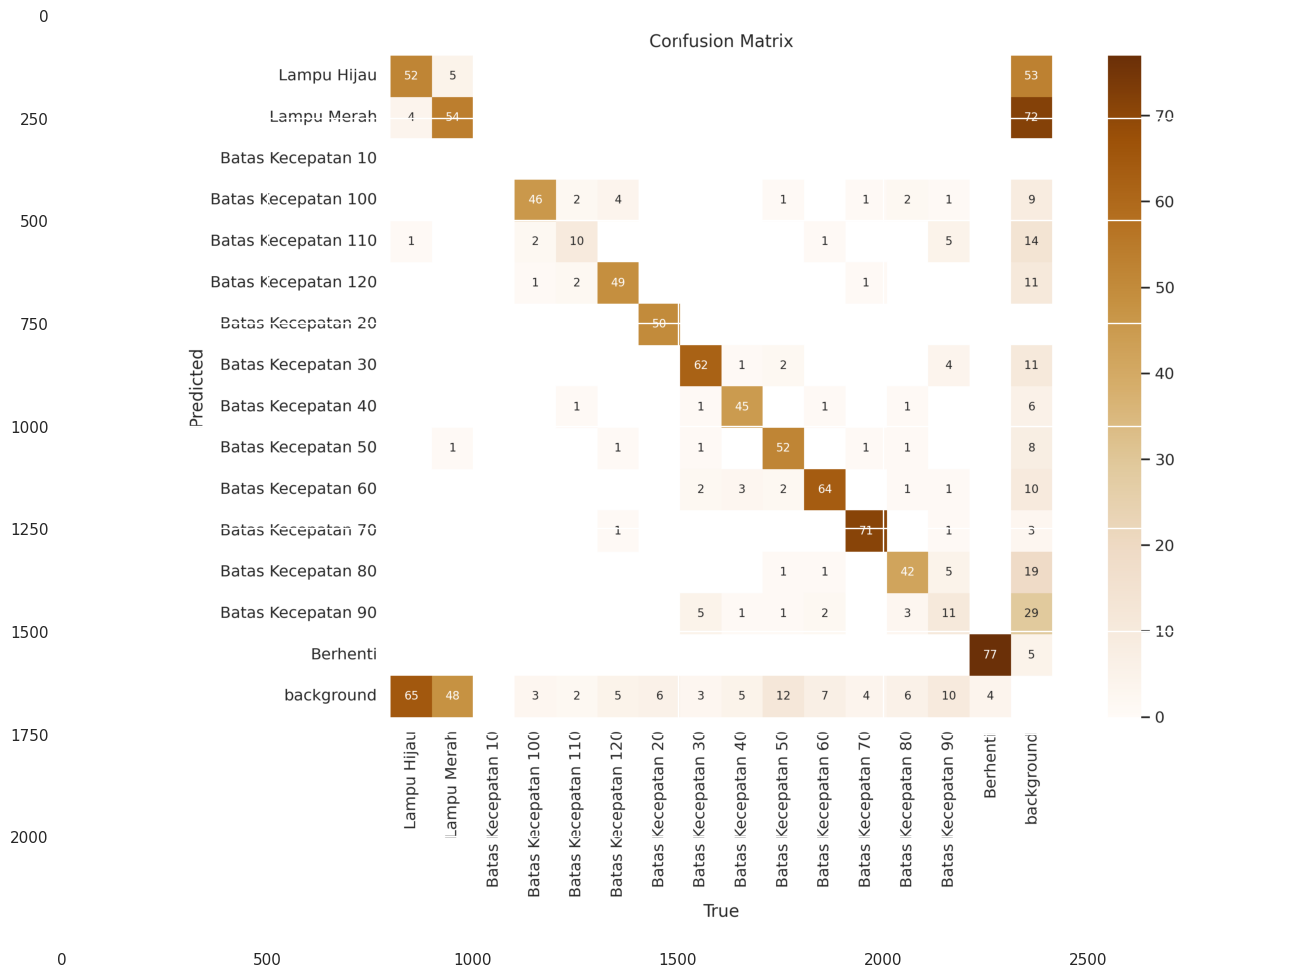

In [ ]:
# Load the image
for i in list_of_metrics:
    image = cv2.imread(f'/content/runs/detect/train12/{i}')

    # Create a larger figure
    plt.figure(figsize=(16, 12))

    # Display the image
    plt.imshow(image)

    # Show the plot
    plt.show()

In [ ]:
Result_Final_model = pd.read_csv('/content/runs/detect/train12/results.csv')
Result_Final_model.tail(50)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,595.067,1.03834,3.00311,1.11705,0.11124,0.48346,0.13777,0.10912,1.05746,3.03962,1.06791,0.067019,0.000333,0.000333
1,2,1183.790,0.92572,2.36285,1.10076,0.15485,0.54172,0.18243,0.13933,0.96851,2.20533,1.04262,0.034006,0.000653,0.000653
2,3,1761.620,0.87538,2.12620,1.09270,0.16728,0.51485,0.19092,0.15387,0.93473,2.14481,1.02056,0.000979,0.000960,0.000960
3,4,2335.450,0.84414,2.01306,1.07142,0.18967,0.52180,0.21462,0.17579,0.96125,1.94836,1.00432,0.000941,0.000941,0.000941
4,5,2914.980,0.79902,1.93125,1.05455,0.23031,0.50530,0.23817,0.19296,0.92891,1.92022,0.99886,0.000921,0.000921,0.000921
5,6,3496.040,0.80395,1.88872,1.05329,0.18846,0.56341,0.26210,0.21133,0.90736,1.79562,0.97140,0.000901,0.000901,0.000901
6,7,4077.390,0.78566,1.81611,1.04212,0.26626,0.52465,0.26425,0.21434,0.90442,1.92458,0.98439,0.000881,0.000881,0.000881
7,8,4656.910,0.78416,1.80647,1.03969,0.18946,0.57946,0.25828,0.20991,0.87179,1.94748,0.96197,0.000861,0.000861,0.000861
8,9,5232.930,0.73542,1.75082,1.02231,0.23880,0.54072,0.28972,0.24257,0.83242,1.87682,0.95219,0.000842,0.000842,0.000842
9,10,5807.830,0.73913,1.72830,1.02381,0.23389,0.58871,0.28438,0.23492,0.80925,1.94521,0.94169,0.000822,0.000822,0.000822


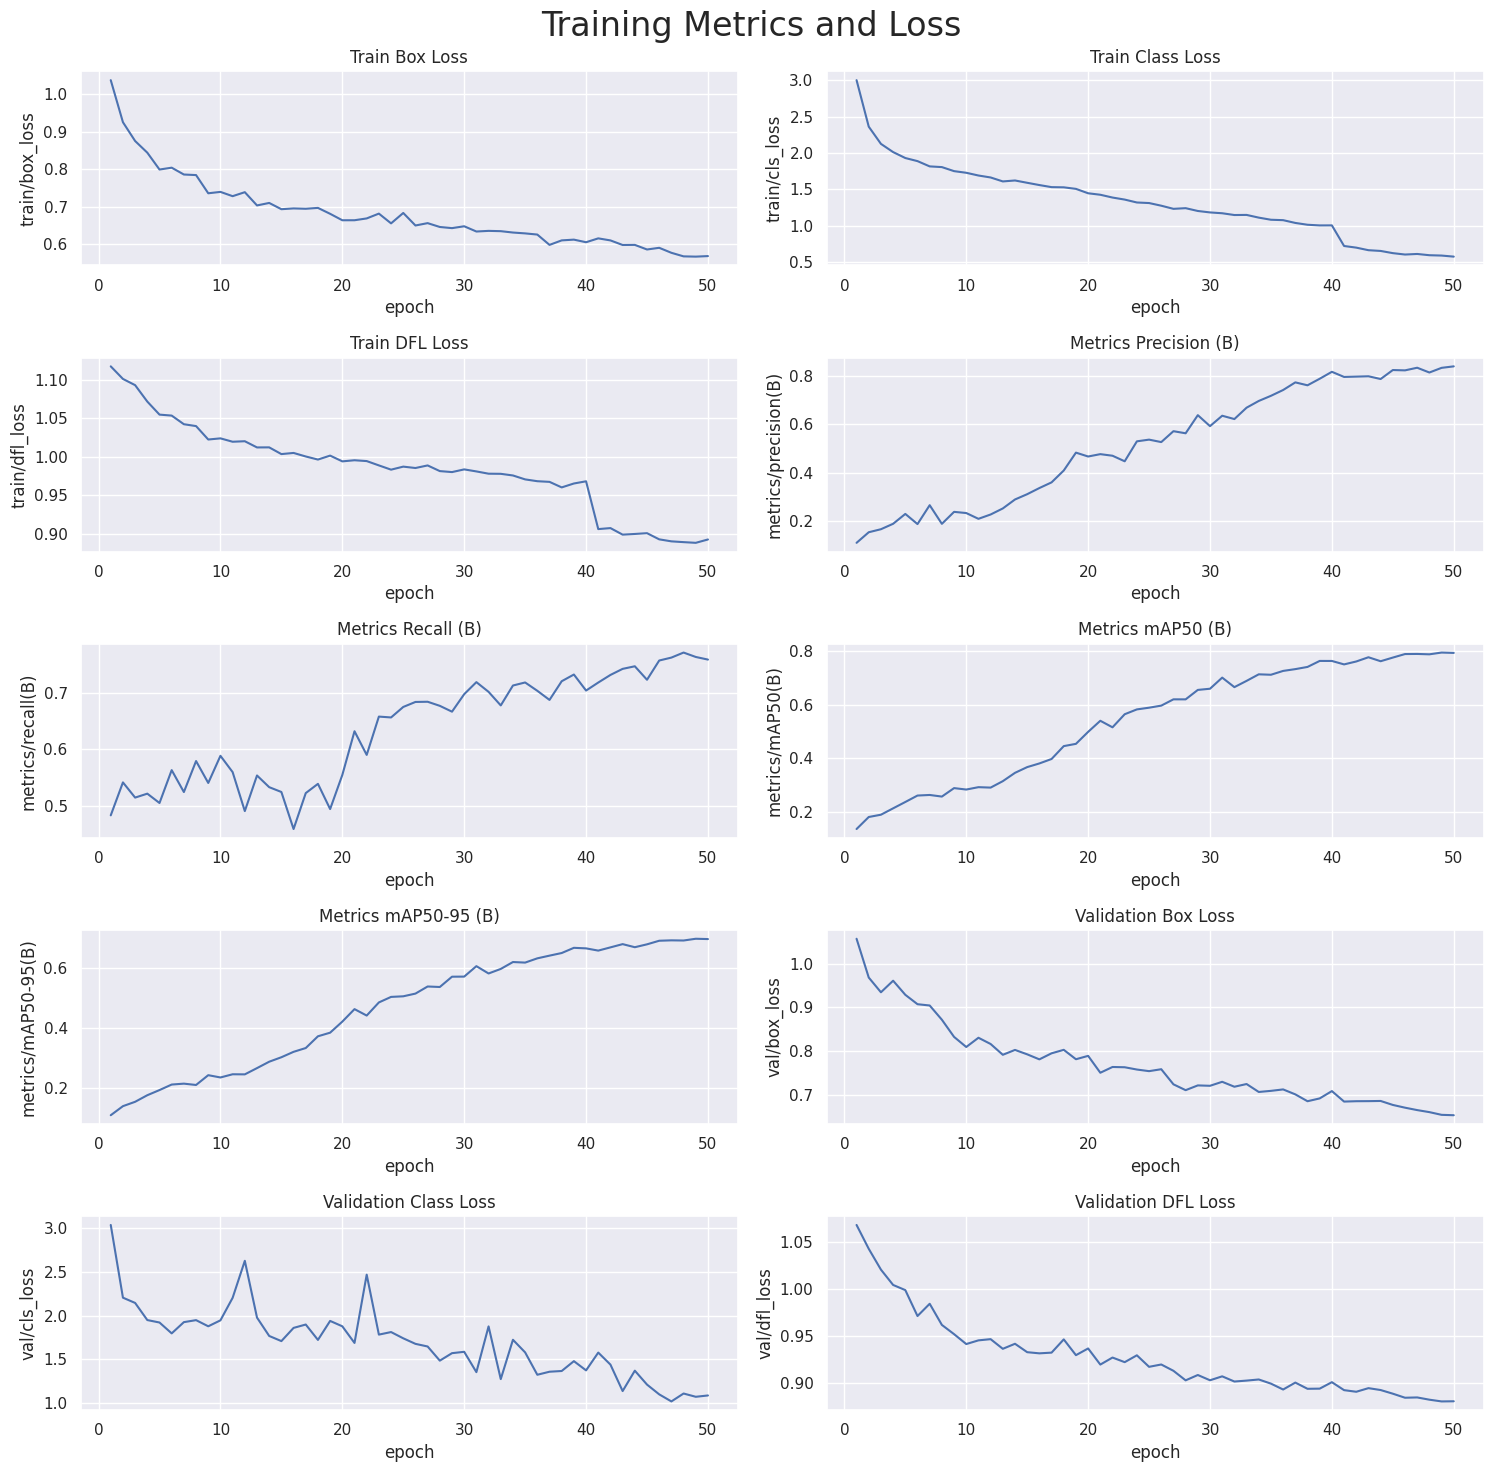

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the results.csv file as a pandas dataframe
Result_Final_model = pd.read_csv('/content/runs/detect/train12/results.csv')
Result_Final_model.columns = Result_Final_model.columns.str.strip()

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

# Plot the columns using seaborn
sns.lineplot(x='epoch', y='train/box_loss', data=Result_Final_model, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=Result_Final_model, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=Result_Final_model, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=Result_Final_model, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=Result_Final_model, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=Result_Final_model, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=Result_Final_model, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=Result_Final_model, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=Result_Final_model, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=Result_Final_model, ax=axs[4,1])

# Set titles and axis labels for each subplot
axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')

plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()


In [ ]:
# Loading the best performing model
Valid_model = YOLO('/content/runs/detect/train12/weights/best.pt')

# Evaluating the model on the testset
metrics = Valid_model.val(split = 'test')

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 41.8±53.5 MB/s, size: 8.3 KB)


val: Scanning /content/datapalangnew/test/labels.cache... 467 images, 1 backgrounds, 1 corrupt: 100%|██████████| 468/468 [00:00<?, ?it/s]

val: /content/datapalangnew/test/images/000231_jpg.rf.71b28020e16b2c6b5aa86d24726609c8.jpg: ignoring corrupt image/label: cannot identify image file '/content/datapalangnew/test/images/000231_jpg.rf.71b28020e16b2c6b5aa86d24726609c8.jpg'



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 30/30 [00:24<00:00,  1.23it/s]


                   all        467        551      0.776       0.62      0.676      0.597
           Lampu Hijau         45         60      0.332      0.381      0.243      0.143
           Lampu Merah         54         64      0.378      0.391      0.233      0.151
    Batas Kecepatan 10          2          3          1          0      0.277      0.235
   Batas Kecepatan 100         32         32       0.83      0.875      0.879       0.77
   Batas Kecepatan 110          4          4          0          0     0.0138     0.0067
   Batas Kecepatan 120         26         26       0.86      0.962      0.961      0.876
    Batas Kecepatan 20         46         46      0.976      0.826      0.955      0.843
    Batas Kecepatan 30         51         51      0.952      0.804      0.887      0.844
    Batas Kecepatan 40         37         39       0.97      0.816      0.939      0.809
    Batas Kecepatan 50         45         48      0.912      0.688       0.79      0.719
    Batas Kecepatan 6

In [ ]:
# final results
print("precision(B): ", metrics.results_dict["metrics/precision(B)"])
print("metrics/recall(B): ", metrics.results_dict["metrics/recall(B)"])
print("metrics/mAP50(B): ", metrics.results_dict["metrics/mAP50(B)"])
print("metrics/mAP50-95(B): ", metrics.results_dict["metrics/mAP50-95(B)"])

precision(B):  0.7756926361037343
metrics/recall(B):  0.6196284829350829
metrics/mAP50(B):  0.6758201910992984
metrics/mAP50-95(B):  0.597051401734551


In [ ]:
# Path to the directory containing the images
image_dir = '/content/datapalangnew/test/images'

# Get a list of all image files in the directory
image_files = [os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith('.jpg')]

# Randomly select 10 images from the directory
random_images = random.sample(image_files, k=10)

for image_path in random_images:
    image = cv2.imread(image_path)  # Replace with your preferred method of reading the image
    results = Final_model.predict([image], save=True, imgsz=416, conf=0.5, iou=0.7)
    #results.append(result)


0: 416x416 1 Batas Kecepatan 60, 100.0ms
Speed: 2.8ms preprocess, 100.0ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/train122

0: 416x416 (no detections), 93.9ms
Speed: 2.7ms preprocess, 93.9ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/train123

0: 416x416 1 Lampu Merah, 1 Batas Kecepatan 30, 91.2ms
Speed: 2.6ms preprocess, 91.2ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/train124

0: 416x416 1 Batas Kecepatan 60, 92.0ms
Speed: 3.6ms preprocess, 92.0ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/train125

0: 416x416 1 Berhenti, 113.4ms
Speed: 2.4ms preprocess, 113.4ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/train126

0: 416x416 (no detections), 91.7ms
Speed: 2.9ms preprocess, 91.7ms inference, 0.6ms postprocess per image at shape 

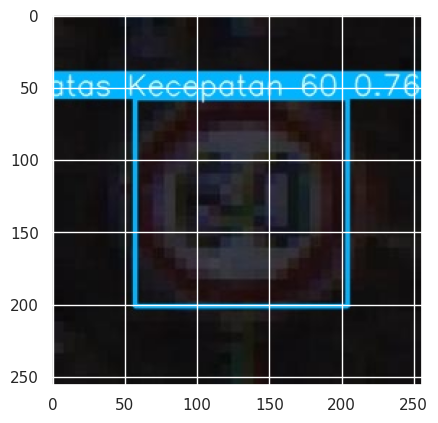

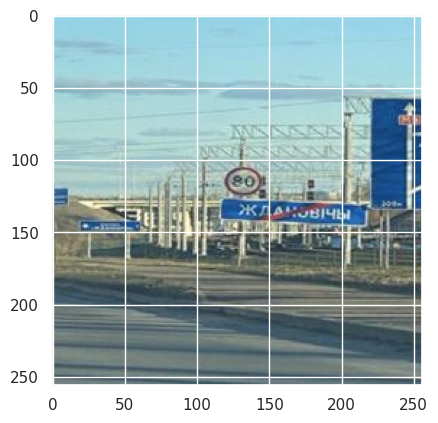

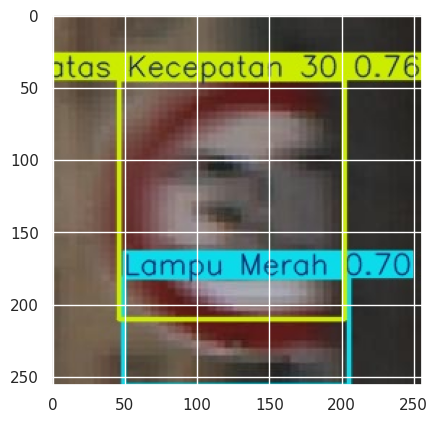

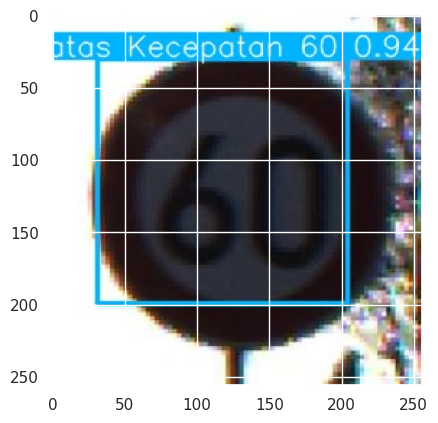

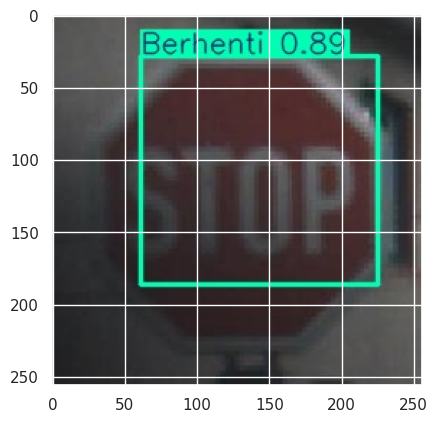

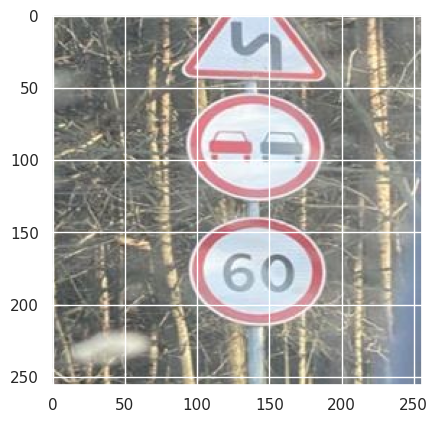

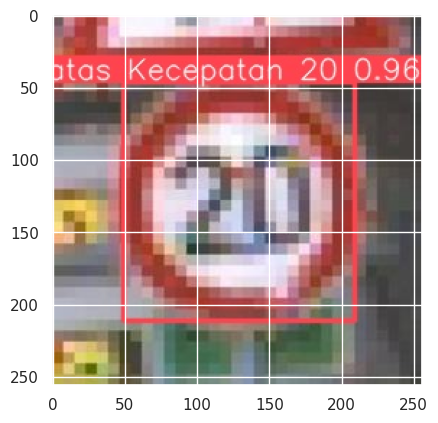

In [ ]:
# View results
for i in range(2, 9):
    # Updated path to reflect likely save location of images
    image_path = f'/content/runs/detect/train12{i}/image0.jpg'

    # Check if the file exists before attempting to read it
    if os.path.exists(image_path):
        plt.imshow(plt.imread(image_path))
        plt.show()
    else:
        print(f"Image file not found: {image_path}")

In [ ]:
from ultralytics import YOLO

ModuleNotFoundError: No module named 'ultralytics'


image 1/1 /content/drive/MyDrive/Colab Notebooks/PCD DETECTION YOLO/datapalangnew/test/images/00007_00042_00000_png.rf.b6fa9ef6ce63f92b01992d4ea8d63f5a.jpg: 416x416 1 Batas Kecepatan 50, 88.0ms
Speed: 4.7ms preprocess, 88.0ms inference, 26.9ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/predict2


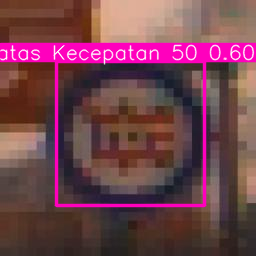

In [ ]:
# Load the best performing model
Valid_model = YOLO('/content/drive/MyDrive/Colab Notebooks/PCD DETECTION YOLO/runs/detect/train12/weights/best.pt')

# Choose a single image for testing
image_path = '/content/drive/MyDrive/Colab Notebooks/PCD DETECTION YOLO/datapalangnew/test/images/00007_00042_00000_png.rf.b6fa9ef6ce63f92b01992d4ea8d63f5a.jpg'

# Perform inference
results = Valid_model.predict(source=image_path, save=True, imgsz=416, conf=0.5)

# Display the image with predictions
for result in results:
    plotted_image = result.plot()
    display(Image.fromarray(plotted_image))
